# Intelligent Customer Review Analysis — McDonald's Reviews

Objectif (pour le moment) :
- Exploration et préparation des données
- Analyse statistique des données
- Visualisation des distributions
- Gestion de la normalisation / standardisation / données manquantes
- Graphe comparatif : avant vs après prétraitement
- Séparation en jeux train / validation / test

Le CSV contient : `reviewer_id`, `store_name`, `category`, `store_address`, `latitude`, `longitude`, `rating_count`, `review_time`, `review`, `rating`.

## 1) Import & configuration
Chargement des librairies et réglages d'affichage (pandas / seaborn).

In [20]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

## 2) Chargement des données
Lecture du fichier CSV et premier aperçu (shape + head).

In [21]:
# Chargement
DATA_PATH = Path('McDonald_s_Reviews.csv')
assert DATA_PATH.exists(), f'CSV introuvable: {DATA_PATH.resolve()}'

df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head(5))

# Remarque: dans ce dataset, certains noms de colonnes peuvent contenir des espaces (ex: "latitude "),
# et `rating`/`rating_count` peuvent être stockés en texte (ex: "4 stars", "1,240").

Shape: (33396, 10)


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was �����������...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


## 3) Exploration rapide
Types de colonnes, valeurs manquantes, et doublons.

In [22]:
# Exploration rapide
display(df_raw.info())

missing = (df_raw.isna().mean() * 100).sort_values(ascending=False)
display(missing.to_frame('missing_%').head(20))

dup_count = df_raw.duplicated().sum()
print('Duplicates:', dup_count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB


None

,missing_%
latitude,1.976285
longitude,1.976285
store_name,0.000000
reviewer_id,0.000000
store_address,0.000000
category,0.000000
rating_count,0.000000
review_time,0.000000
review,0.000000
rating,0.000000


Duplicates: 0


## 4) Préparation / nettoyage
Nettoyage des noms de colonnes, parsing des champs (rating, rating_count, review_time) et création de variables simples (review_length).

In [23]:
# Nettoyage / préparation des colonnes
df = df_raw.copy()

# 1) Normaliser les noms de colonnes (trim espaces, snake-case léger)
df.columns = [c.strip() for c in df.columns]

# 2) Parsing `rating` (ex: '4 stars', '1 star') -> int (1..5)
def parse_rating(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    m = re.search(r'(\d+)', s)
    return float(m.group(1)) if m else np.nan

if 'rating' in df.columns:
    df['rating'] = df['rating'].apply(parse_rating)

# 2b) Classification sentiment (3 classes) à partir du rating
# Règle: 1-2 = négatif, 3 = neutre, 4-5 = positif
def rating_to_sentiment(r):
    if pd.isna(r):
        return np.nan
    try:
        r_int = int(float(r))
    except (TypeError, ValueError):
        return np.nan

    if r_int <= 2:
        return 'négatif'
    if r_int == 3:
        return 'neutre'
    return 'positif'

if 'rating' in df.columns:
    df['sentiment'] = df['rating'].apply(rating_to_sentiment)

# 3) Parsing `rating_count` (ex: '1,240') -> int
def parse_int_with_commas(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # supprimer tout ce qui n'est pas chiffre
    s = re.sub(r'[^0-9]', '', s)
    return float(s) if s != '' else np.nan

if 'rating_count' in df.columns:
    df['rating_count'] = df['rating_count'].apply(parse_int_with_commas)

# 4) Cast latitude/longitude
for col in ['latitude', 'longitude']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 5) review_time -> approx jours (ex: '5 days ago', '3 months ago', 'a year ago')
def review_time_to_days(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'a day ago', '1 day ago'}:
        return 1.0
    if s in {'a week ago', '1 week ago'}:
        return 7.0
    if s in {'a month ago', '1 month ago'}:
        return 30.0
    if s in {'a year ago', '1 year ago'}:
        return 365.0

    m = re.search(r'(\d+)\s*(day|days|week|weeks|month|months|year|years)\s+ago', s)
    if not m:
        return np.nan
    n = float(m.group(1))
    unit = m.group(2)
    if unit.startswith('day'):
        return n
    if unit.startswith('week'):
        return n * 7.0
    if unit.startswith('month'):
        return n * 30.0
    if unit.startswith('year'):
        return n * 365.0
    return np.nan

if 'review_time' in df.columns:
    df['review_time_days'] = df['review_time'].apply(review_time_to_days)

# 6) Feature simple: longueur du texte
if 'review' in df.columns:
    df['review_length'] = df['review'].astype(str).str.len().replace({0: np.nan})

display(df.head(5))
display(df.describe(include='all').T.head(25))

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating,sentiment,review_time_days,review_length
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,3 months ago,Why does it look like someone spit on my food?...,1.0,négatif,90.0,259
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,5 days ago,It'd McDonalds. It is what it is as far as the...,4.0,positif,5.0,237
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,5 days ago,Made a mobile order got to the speaker and che...,1.0,négatif,5.0,360
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,a month ago,My mc. Crispy chicken sandwich was �����������...,5.0,positif,30.0,104
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,2 months ago,"I repeat my order 3 times in the drive thru, a...",1.0,négatif,60.0,312


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
reviewer_id,33396.0,NaN,NaN,NaN,16698.5,9640.739131,1.0,8349.75,16698.5,25047.25,33396.0
store_name,33396,2,McDonald's,33325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,33396,1,Fast food restaurant,33396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_address,33396,40,"9814 International Dr, Orlando, FL 32819, Unit...",1890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,32736.0,NaN,NaN,NaN,34.442546,5.344116,25.790295,28.65535,33.931261,40.727401,44.98141
longitude,32736.0,NaN,NaN,NaN,-90.647033,16.594844,-121.995421,-97.792874,-81.471414,-75.399919,-73.45982
rating_count,33396.0,NaN,NaN,NaN,2582.135286,2507.312674,263.0,1406.0,1795.0,2810.0,19682.0
review_time,33396,39,4 years ago,6740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review,33396,22281,Excellent,2148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,33396.0,NaN,NaN,NaN,3.131363,1.615139,1.0,1.0,3.0,5.0,5.0


## 5) Analyse statistique
Statistiques descriptives et agrégats (par catégorie, par store, corrélations).

In [24]:
# Analyse statistique (quelques agrégats utiles)
if 'rating' in df.columns:
    print('Rating stats:')
    display(df['rating'].describe())

if {'store_address', 'rating'}.issubset(df.columns):
    print('Top stores (nb reviews):')
    display(df.groupby('store_address', dropna=False)['rating'].agg(['count', 'mean']).sort_values('count', ascending=False).head(10))

if {'rating_count', 'rating'}.issubset(df.columns):
    print('Corr (rating_count vs rating):')
    corr_df = df[['rating_count', 'rating']].corr(numeric_only=True)
    display(corr_df)
    corr_val = float(corr_df.loc['rating_count', 'rating'])
    print(f"Interprétation: corrélation de Pearson = {corr_val:.3f}.")
    print("→ Valeur proche de 0 : relation linéaire très faible (quasi inexistante) entre le nombre total d'avis d'un magasin et la note donnée dans un avis.")

Rating stats:


count    33396.000000
mean         3.131363
std          1.615139
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

Top stores (nb reviews):


,count,mean
store_address,,
"9814 International Dr, Orlando, FL 32819, United States",1890,2.579894
"5725 W Irlo Bronson Memorial Hwy, Kissimmee, FL 34746, United States",1720,2.810465
"10901 Riverside Dr, North Hollywood, CA 91602, United States",1710,3.377193
"1415 E State Rd, Fern Park, FL 32730, United States",1700,3.470588
"632 S R L Thornton Freeway Service Rd, Dallas, TX 75203, United States",1650,3.143636
"3501 Biscayne Blvd, Miami, FL 33137, United States",1570,2.557962
"621 Broadway, Newark, NJ 07104, United States",1290,2.993023
"1100 N US Hwy 377, Roanoke, TX 76262, United States",1168,3.465753
"724 Broadway, New York, NY 10003, United States",1140,3.312281


Corr (rating_count vs rating):


,rating_count,rating
rating_count,1.000000,-0.051163
rating,-0.051163,1.000000


Interprétation: corrélation de Pearson = -0.051.
→ Valeur proche de 0 : relation linéaire très faible (quasi inexistante) entre le nombre total d'avis d'un magasin et la note donnée dans un avis.


## 6) Visualisation des distributions
Histogrammes / countplots des variables clés (avant prétraitement) + aperçu des valeurs manquantes.

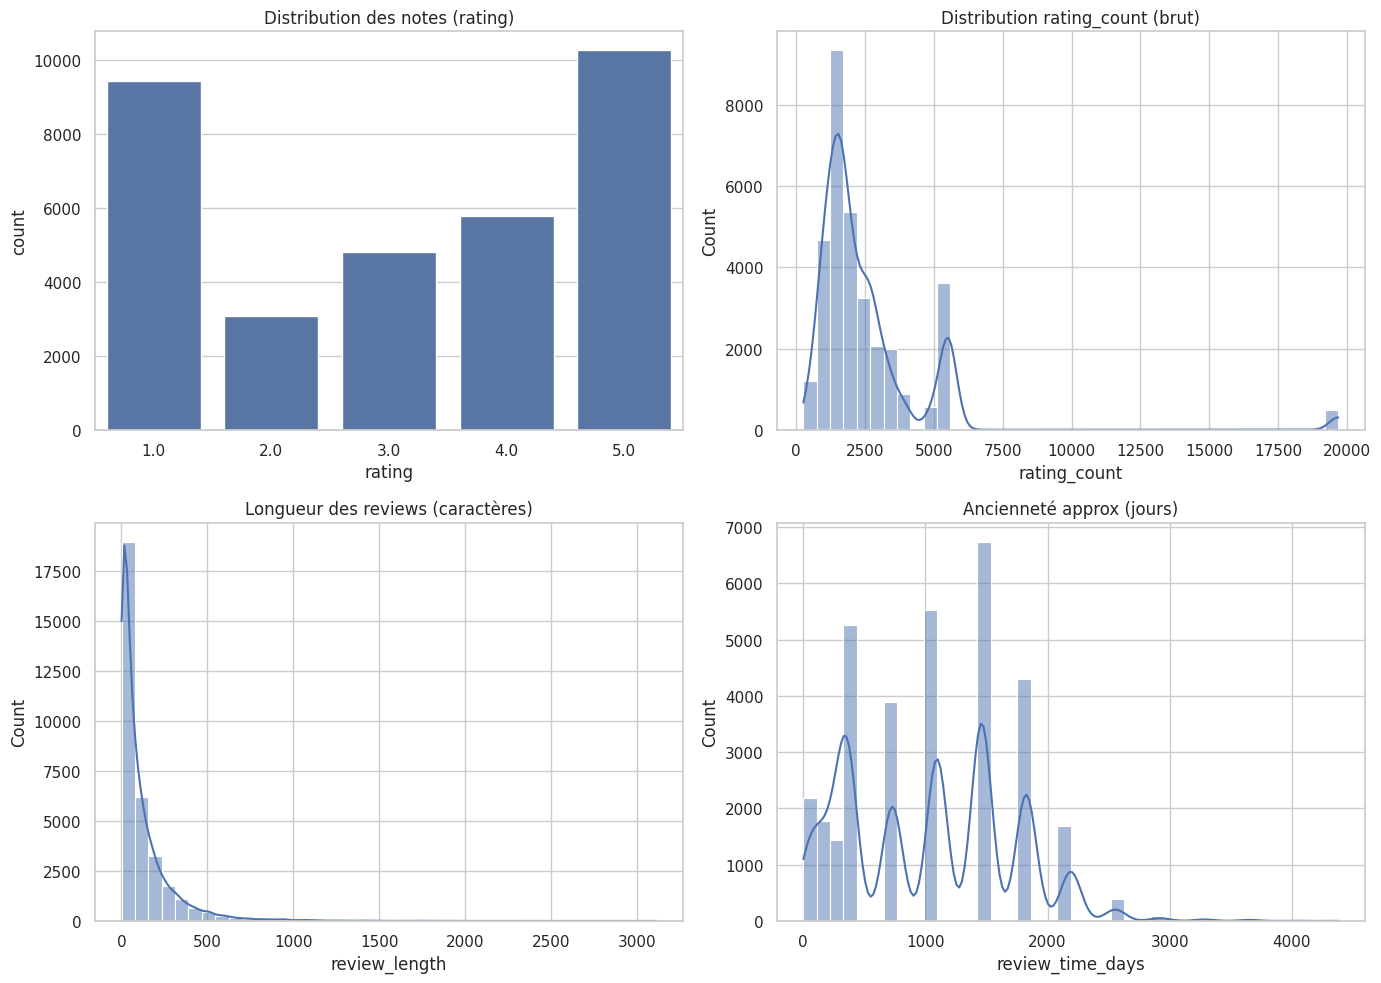

In [ ]:
# Visualisation des distributions (AVANT prétraitement)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

if 'rating' in df.columns:
    sns.countplot(x='rating', data=df, ax=axes[0])
    axes[0].set_title('Distribution des notes (rating)')
else:
    axes[0].axis('off')

if 'rating_count' in df.columns:
    sns.histplot(df['rating_count'].dropna(), bins=40, kde=True, ax=axes[1])
    axes[1].set_title('Distribution rating_count (brut)')
else:
    axes[1].axis('off')

if 'review_length' in df.columns:
    sns.histplot(df['review_length'].dropna(), bins=40, kde=True, ax=axes[2])
    axes[2].set_title('Longueur des reviews (caractères)')
else:
    axes[2].axis('off')

if 'review_time_days' in df.columns:
    sns.histplot(df['review_time_days'].dropna(), bins=40, kde=True, ax=axes[3])
    axes[3].set_title('Ancienneté approx (jours)')
else:
    axes[3].axis('off')

plt.tight_layout()
plt.show()

## 7) Prétraitement (valeurs manquantes + standardisation)
Imputation des variables numériques (médiane) et standardisation (z-score).

In [26]:
# Prétraitement: gestion NA + standardisation (numériques)
numeric_cols = [c for c in ['latitude', 'longitude', 'rating_count', 'review_time_days', 'review_length'] if c in df.columns]
print('Numeric cols:', numeric_cols)

df_num_before = df[numeric_cols].copy()

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

num_imputed = imputer.fit_transform(df_num_before)
num_scaled = scaler.fit_transform(num_imputed)

df_num_after = pd.DataFrame(num_scaled, columns=[f'{c}_z' for c in numeric_cols], index=df.index)

df_pre = df.copy()
for c in numeric_cols:
    # version imputée (non-scalée) pour garder un dataset propre
    df_pre[c] = num_imputed[:, numeric_cols.index(c)]

df_pre = pd.concat([df_pre, df_num_after], axis=1)
display(df_pre[[*numeric_cols, *[f'{c}_z' for c in numeric_cols]]].head(5))

print('Missing après imputation (num):')
display(df_pre[numeric_cols].isna().mean().to_frame('missing_ratio'))

Numeric cols: ['latitude', 'longitude', 'rating_count', 'review_time_days', 'review_length']


,latitude,longitude,rating_count,review_time_days,review_length,latitude_z,longitude_z,rating_count_z,review_time_days_z,review_length_z
0,30.460718,-97.792874,1240.0,90.0,259.0,-0.750594,-0.444628,-0.535296,-1.406471,0.780727
1,30.460718,-97.792874,1240.0,5.0,237.0,-0.750594,-0.444628,-0.535296,-1.532878,0.656274
2,30.460718,-97.792874,1240.0,5.0,360.0,-0.750594,-0.444628,-0.535296,-1.532878,1.352079
3,30.460718,-97.792874,1240.0,30.0,104.0,-0.750594,-0.444628,-0.535296,-1.495700,-0.096101
4,30.460718,-97.792874,1240.0,60.0,312.0,-0.750594,-0.444628,-0.535296,-1.451085,1.080546


Missing après imputation (num):


,missing_ratio
latitude,0.0
longitude,0.0
rating_count,0.0
review_time_days,0.0
review_length,0.0


## 8) Comparaison avant / après prétraitement
Graphiques comparatifs pour visualiser l'effet de la standardisation sur les distributions (avant vs après).

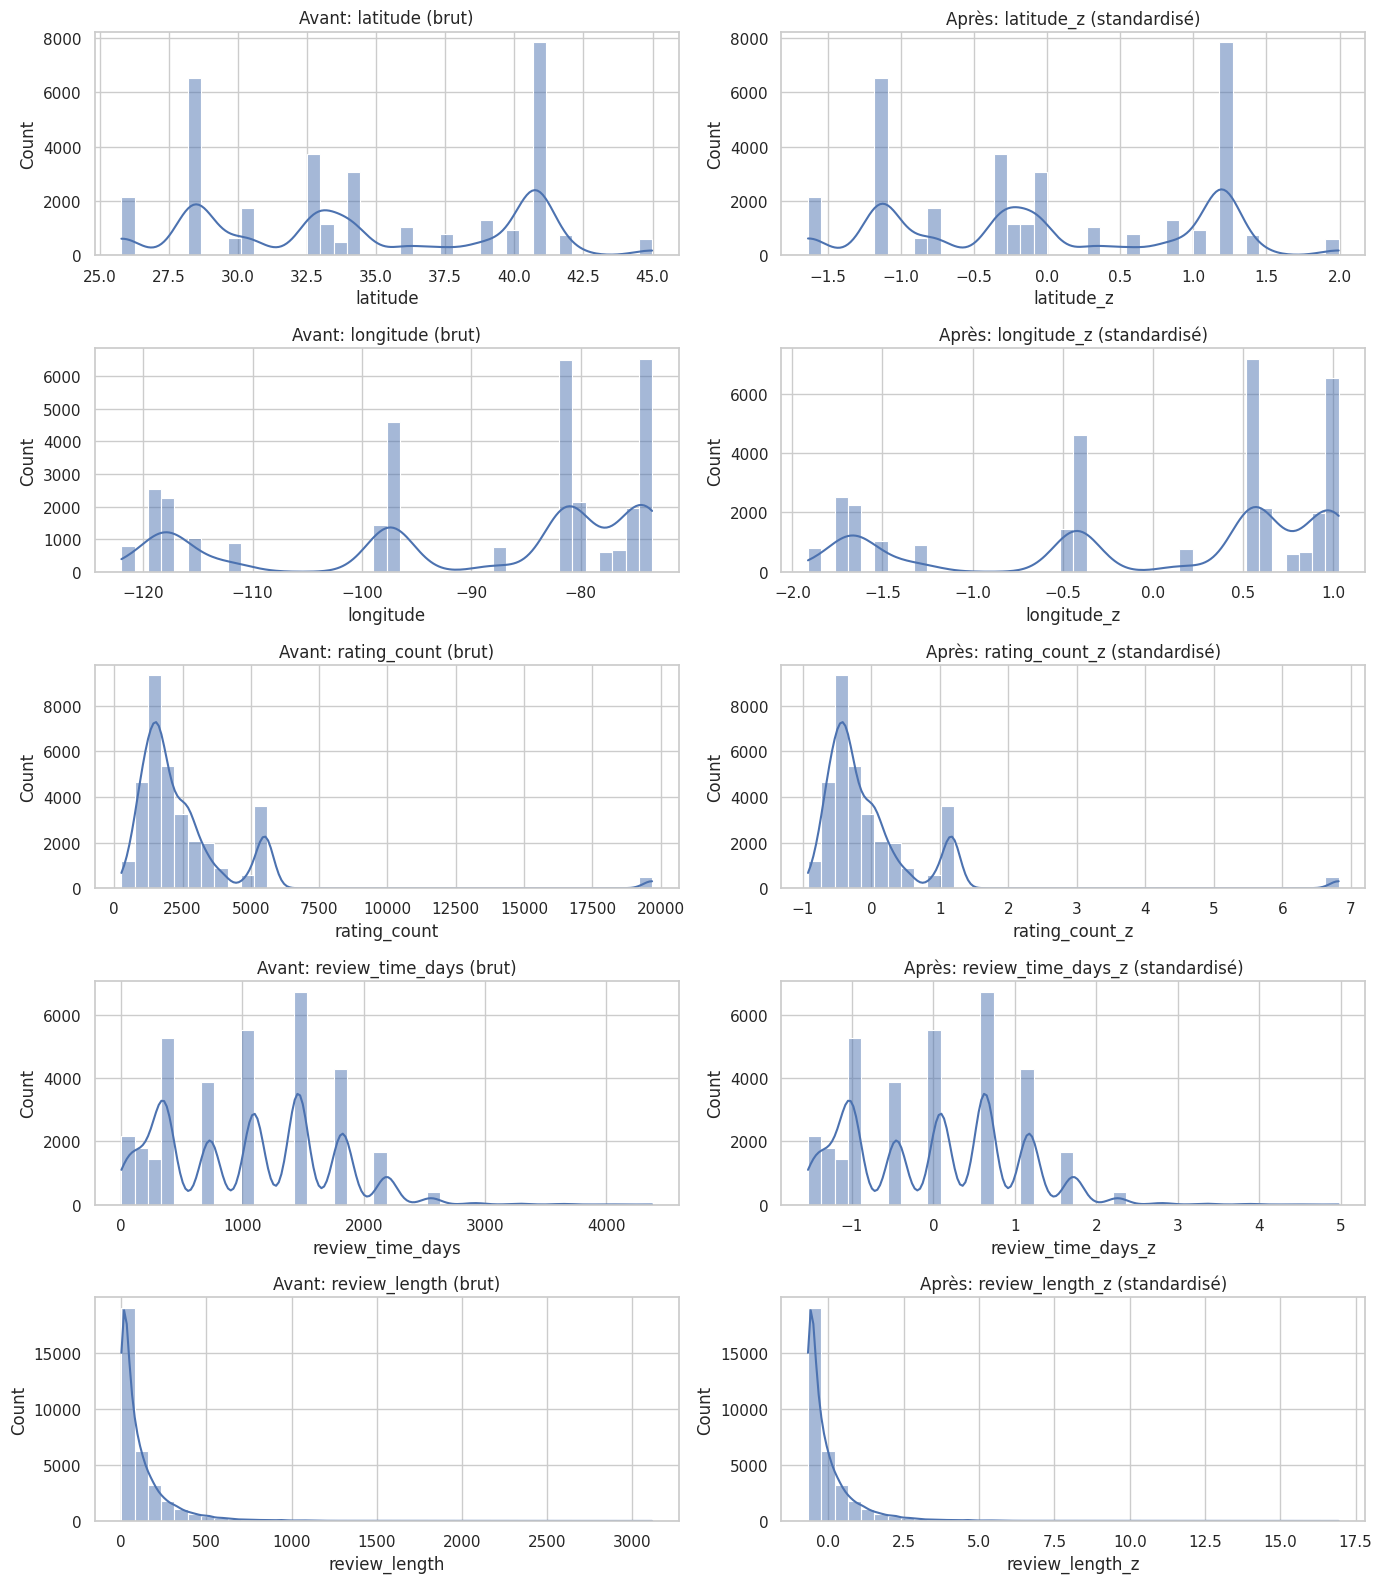

In [27]:
# Graphe comparatif: AVANT vs APRES (standardisation)
# On compare les distributions des colonnes numériques brutes vs leurs versions z-score
if numeric_cols:
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 3.2 * len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = np.array([axes])

    for i, c in enumerate(numeric_cols):
        sns.histplot(df_num_before[c].dropna(), bins=40, kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Avant: {c} (brut)')

        sns.histplot(df_pre[f'{c}_z'].dropna(), bins=40, kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f'Après: {c}_z (standardisé)')

    plt.tight_layout()
    plt.show()
else:
    print('Aucune colonne numérique détectée pour la comparaison avant/après.')

## 9) Split train / validation / test
Séparation stratifiée (sur la *target* choisie : `rating` ou `sentiment`) en 70/15/15 et vérification des distributions.

In [28]:
# Séparation train / validation / test
# Choix de la target:
# - 'rating' (1..5) : prédire la note
# - 'sentiment' (négatif/neutre/positif) : classification 3 classes dérivée du rating

TARGET_COL = 'sentiment'  # <-- changez ici si vous préférez 'rating'

assert TARGET_COL in df_pre.columns, f"Colonne target `{TARGET_COL}` manquante."

df_ml = df_pre.dropna(subset=[TARGET_COL]).copy()

# Si on prédit le rating, on force un int propre
if TARGET_COL == 'rating':
    df_ml['rating'] = df_ml['rating'].astype(int)

feature_cols = []
for c in ['review', 'store_name', 'category', 'store_address']:
    if c in df_ml.columns:
        feature_cols.append(c)

# Ajoute les features numériques imputées + versions z-score
for c in numeric_cols:
    if c in df_ml.columns:
        feature_cols.append(c)
    zc = f'{c}_z'
    if zc in df_ml.columns:
        feature_cols.append(zc)

X = df_ml[feature_cols]
y = df_ml[TARGET_COL]

# 70% train, 15% val, 15% test (stratifié sur la target)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print('Target:', TARGET_COL)
print('Shapes:')
print('  Train:', X_train.shape, y_train.shape)
print('  Val  :', X_val.shape, y_val.shape)
print('  Test :', X_test.shape, y_test.shape)

# Vérif distribution de la target
_dist_train = y_train.value_counts(normalize=True, dropna=False) * 100
_dist_val = y_val.value_counts(normalize=True, dropna=False) * 100
_dist_test = y_test.value_counts(normalize=True, dropna=False) * 100

dist = pd.DataFrame({
    'train_%': _dist_train,
    'val_%': _dist_val,
    'test_%': _dist_test,
}).fillna(0)

display(dist.sort_index() if TARGET_COL == 'rating' else dist.loc[dist.index.sort_values()])

Target: sentiment
Shapes:
  Train: (23377, 14) (23377,)
  Val  : (5009, 14) (5009,)
  Test : (5010, 14) (5010,)


,train_%,val_%,test_%
sentiment,,,
neutre,14.424434,14.434019,14.431138
négatif,37.481285,37.472549,37.485030
positif,48.094281,48.093432,48.083832


## 10) Préparation des features pour le ML
Vectorisation du texte (TF-IDF) et encodage des variables catégorielles pour créer un dataset prêt pour l'entraînement.

## 10.1) Gestion des performances (Cache & Batch Processing)
Optimisation des performances avec mise en cache des résultats intermédiaires et traitement par lots.

In [29]:
import pickle
import hashlib
import json
from pathlib import Path
from datetime import datetime

# Configuration du cache
CACHE_DIR = Path('.cache')
CACHE_DIR.mkdir(exist_ok=True)

class PerformanceManager:
    """
    Gestionnaire de performances pour optimiser les calculs via cache et batch processing.
    """
    
    def __init__(self, cache_dir=CACHE_DIR):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self.cache_log = {}
        
    def _get_cache_key(self, identifier, params=None):
        """Génère une clé de cache unique basée sur l'identifiant et les paramètres."""
        if params:
            param_str = json.dumps(params, sort_keys=True)
            hash_obj = hashlib.md5(f"{identifier}_{param_str}".encode())
            return f"{identifier}_{hash_obj.hexdigest()[:8]}"
        return identifier
    
    def cache_exists(self, key):
        """Vérifie si un cache existe."""
        cache_file = self.cache_dir / f"{key}.pkl"
        return cache_file.exists()
    
    def save_to_cache(self, key, data, metadata=None):
        """Sauvegarde des données dans le cache."""
        cache_file = self.cache_dir / f"{key}.pkl"
        
        cache_data = {
            'data': data,
            'timestamp': datetime.now().isoformat(),
            'metadata': metadata or {}
        }
        
        with open(cache_file, 'wb') as f:
            pickle.dump(cache_data, f)
        
        self.cache_log[key] = {
            'saved_at': cache_data['timestamp'],
            'file': str(cache_file)
        }
        
        print(f"✓ Cache sauvegardé: {key} ({cache_file.stat().st_size / 1024:.1f} KB)")
        return cache_file
    
    def load_from_cache(self, key):
        """Charge des données depuis le cache."""
        cache_file = self.cache_dir / f"{key}.pkl"
        
        if not cache_file.exists():
            return None
        
        with open(cache_file, 'rb') as f:
            cache_data = pickle.load(f)
        
        print(f"✓ Cache chargé: {key} (sauvegardé le {cache_data['timestamp']})")
        return cache_data['data']
    
    def clear_cache(self, pattern=None):
        """Supprime les fichiers de cache."""
        if pattern:
            files = list(self.cache_dir.glob(f"{pattern}*.pkl"))
        else:
            files = list(self.cache_dir.glob("*.pkl"))
        
        for f in files:
            f.unlink()
        
        print(f"✓ {len(files)} fichier(s) de cache supprimé(s)")
    
    def batch_predict(self, model, X, batch_size=1000):
        """
        Effectue des prédictions par lots pour économiser la mémoire.
        
        Args:
            model: modèle entraîné
            X: features (sparse matrix ou array)
            batch_size: taille des lots
        
        Returns:
            predictions: array des prédictions
        """
        n_samples = X.shape[0]
        predictions = []
        
        print(f"→ Prédiction par lots (batch_size={batch_size})...")
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            batch_X = X[i:end_idx]
            batch_pred = model.predict(batch_X)
            predictions.extend(batch_pred)
            
            if (i // batch_size + 1) % 10 == 0:
                print(f"  Traité: {end_idx}/{n_samples} échantillons")
        
        print(f"✓ Prédictions complètes: {len(predictions)} échantillons")
        return np.array(predictions)
    
    def get_cache_info(self):
        """Retourne des informations sur le cache."""
        cache_files = list(self.cache_dir.glob("*.pkl"))
        total_size = sum(f.stat().st_size for f in cache_files)
        
        info = {
            'cache_dir': str(self.cache_dir),
            'n_files': len(cache_files),
            'total_size_mb': total_size / (1024 * 1024),
            'files': [f.name for f in cache_files]
        }
        
        return info


# Initialisation du gestionnaire de performances
perf_manager = PerformanceManager()

# Afficher les infos du cache
cache_info = perf_manager.get_cache_info()
print(f"📁 Cache directory: {cache_info['cache_dir']}")
print(f"📊 Fichiers en cache: {cache_info['n_files']}")
print(f"💾 Taille totale: {cache_info['total_size_mb']:.2f} MB")

if cache_info['files']:
    print(f"📄 Fichiers: {', '.join(cache_info['files'][:5])}")
    if len(cache_info['files']) > 5:
        print(f"    ... et {len(cache_info['files']) - 5} autres")


📁 Cache directory: .cache
📊 Fichiers en cache: 5
💾 Taille totale: 51.33 MB
📄 Fichiers: model_XGBoost_5ba0bb3c.pkl, features_prepared_772c3ef6.pkl, model_MLP_Neural_Network_6dcadc0a.pkl, model_Logistic_Regression_d39a65d9.pkl, model_Random_Forest_5efd86c5.pkl


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

def prepare_features(X_train, X_val, X_test, text_col='review', max_features=5000, use_cache=True):
    """
    Prépare les features pour le machine learning avec gestion du cache.
    - Vectorise le texte avec TF-IDF
    - Encode les variables catégorielles
    - Combine avec les features numériques standardisées
    
    Args:
        X_train, X_val, X_test: DataFrames contenant les features
        text_col: nom de la colonne texte à vectoriser
        max_features: nombre max de features TF-IDF
        use_cache: utiliser le cache si disponible
    
    Returns:
        X_train_prepared, X_val_prepared, X_test_prepared: matrices sparse combinées
        feature_names: liste des noms de features
    """
    
    # Paramètres pour la clé de cache
    cache_params = {
        'text_col': text_col,
        'max_features': max_features,
        'train_shape': X_train.shape,
        'val_shape': X_val.shape,
        'test_shape': X_test.shape
    }
    
    cache_key = perf_manager._get_cache_key('features_prepared', cache_params)
    
    # Vérifier si le cache existe
    if use_cache and perf_manager.cache_exists(cache_key):
        print('=== Chargement des features depuis le cache ===')
        cached_data = perf_manager.load_from_cache(cache_key)
        return (
            cached_data['X_train'],
            cached_data['X_val'],
            cached_data['X_test'],
            cached_data['feature_names']
        )
    
    print('=== Préparation des features (nouveau calcul) ===')
    
    # 1) Vectorisation TF-IDF du texte (reviews)
    tfidf = TfidfVectorizer(max_features=max_features, min_df=3, max_df=0.8, ngram_range=(1, 2))
    
    if text_col in X_train.columns:
        print(f'  → Vectorisation TF-IDF ({max_features} features max)...')
        X_train_text = tfidf.fit_transform(X_train[text_col].fillna(''))
        X_val_text = tfidf.transform(X_val[text_col].fillna(''))
        X_test_text = tfidf.transform(X_test[text_col].fillna(''))
        tfidf_feature_names = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
        print(f'    ✓ TF-IDF: {X_train_text.shape[1]} features')
    else:
        X_train_text = None
        tfidf_feature_names = []
    
    # 2) Encodage des variables catégorielles (Label Encoding simple)
    categorical_cols = ['store_name', 'category', 'store_address']
    categorical_cols = [c for c in categorical_cols if c in X_train.columns]
    
    encoders = {}
    encoded_features = []
    
    if categorical_cols:
        print(f'  → Encodage des variables catégorielles...')
        for col in categorical_cols:
            le = LabelEncoder()
            # Fit sur train + val + test pour avoir toutes les catégories
            all_values = pd.concat([X_train[col], X_val[col], X_test[col]]).fillna('MISSING')
            le.fit(all_values)
            encoders[col] = le
            
            train_encoded = le.transform(X_train[col].fillna('MISSING')).reshape(-1, 1)
            val_encoded = le.transform(X_val[col].fillna('MISSING')).reshape(-1, 1)
            test_encoded = le.transform(X_test[col].fillna('MISSING')).reshape(-1, 1)
            
            encoded_features.append({
                'train': train_encoded,
                'val': val_encoded,
                'test': test_encoded,
                'name': col
            })
        
        print(f'    ✓ Categorical: {len(categorical_cols)} features encodées')
    
    # 3) Features numériques standardisées (version _z)
    numeric_z_cols = [c for c in X_train.columns if c.endswith('_z')]
    
    if numeric_z_cols:
        print(f'  → Extraction des features numériques...')
        X_train_num = X_train[numeric_z_cols].values
        X_val_num = X_val[numeric_z_cols].values
        X_test_num = X_test[numeric_z_cols].values
        print(f'    ✓ Numeric: {len(numeric_z_cols)} features')
    else:
        X_train_num = np.array([]).reshape(len(X_train), 0)
        X_val_num = np.array([]).reshape(len(X_val), 0)
        X_test_num = np.array([]).reshape(len(X_test), 0)
    
    # 4) Combinaison de toutes les features
    print(f'  → Combinaison des features...')
    features_list_train = []
    features_list_val = []
    features_list_test = []
    all_feature_names = []
    
    # Ajouter texte
    if X_train_text is not None:
        features_list_train.append(X_train_text)
        features_list_val.append(X_val_text)
        features_list_test.append(X_test_text)
        all_feature_names.extend(tfidf_feature_names)
    
    # Ajouter catégorielles
    for enc_feat in encoded_features:
        features_list_train.append(enc_feat['train'])
        features_list_val.append(enc_feat['val'])
        features_list_test.append(enc_feat['test'])
        all_feature_names.append(enc_feat['name'])
    
    # Ajouter numériques
    if X_train_num.shape[1] > 0:
        features_list_train.append(X_train_num)
        features_list_val.append(X_val_num)
        features_list_test.append(X_test_num)
        all_feature_names.extend(numeric_z_cols)
    
    # Concatenation horizontale (hstack pour sparse matrices)
    X_train_final = hstack(features_list_train)
    X_val_final = hstack(features_list_val)
    X_test_final = hstack(features_list_test)
    
    print(f'    ✓ TOTAL: {X_train_final.shape[1]} features combinées')
    
    # Sauvegarder dans le cache
    if use_cache:
        cache_data = {
            'X_train': X_train_final,
            'X_val': X_val_final,
            'X_test': X_test_final,
            'feature_names': all_feature_names
        }
        perf_manager.save_to_cache(cache_key, cache_data, metadata=cache_params)
    
    print()
    return X_train_final, X_val_final, X_test_final, all_feature_names


# Préparation des features avec cache
X_train_ml, X_val_ml, X_test_ml, feature_names = prepare_features(
    X_train, X_val, X_test, use_cache=True
)

print('Shapes finales:')
print(f'  Train: {X_train_ml.shape}')
print(f'  Val:   {X_val_ml.shape}')
print(f'  Test:  {X_test_ml.shape}')


=== Chargement des features depuis le cache ===
✓ Cache chargé: features_prepared_772c3ef6 (sauvegardé le 2026-01-08T11:12:24.402842)
Shapes finales:
  Train: (23377, 5008)
  Val:   (5009, 5008)
  Test:  (5010, 5008)


## 11) Définition et entraînement des modèles
Implémentation de 4 modèles de classification avec recherche d'hyperparamètres.

In [31]:
from tqdm.auto import tqdm
import threading
import time as time_module

def train_and_evaluate_model(model, param_grid, X_train, y_train, X_val, y_val, model_name, cv=3, n_iter=10, use_cache=True, verbose=2):
    """
    Entraîne un modèle avec RandomizedSearchCV pour optimiser les hyperparamètres,
    puis évalue les performances sur le jeu de validation. Affiche une barre de progression en temps réel.
    
    Args:
        model: instance du modèle sklearn
        param_grid: dictionnaire des hyperparamètres à tester
        X_train, y_train: données d'entraînement
        X_val, y_val: données de validation
        model_name: nom du modèle (pour affichage)
        cv: nombre de folds pour la validation croisée
        n_iter: nombre de combinaisons aléatoires à tester
        use_cache: utiliser le cache si disponible
        verbose: niveau de verbosité (0=muet, 1=minimal, 2=détaillé avec barre de progression)
    
    Returns:
        best_model: meilleur modèle entraîné
        metrics: dictionnaire des métriques de performance
    """
    print(f'\n{"="*60}')
    print(f'  MODÈLE: {model_name}')
    print(f'{"="*60}')
    
    # Clé de cache pour le modèle
    cache_params = {
        'model_name': model_name,
        'param_grid': str(param_grid),
        'cv': cv,
        'n_iter': n_iter,
        'X_shape': X_train.shape,
        'y_shape': y_train.shape
    }
    cache_key = perf_manager._get_cache_key(f'model_{model_name.replace(" ", "_")}', cache_params)
    
    # Vérifier si le modèle est en cache
    if use_cache and perf_manager.cache_exists(cache_key):
        print('→ Chargement du modèle depuis le cache...')
        cached_data = perf_manager.load_from_cache(cache_key)
        best_model = cached_data['model']
        
        print(f'✓ Meilleurs hyperparamètres: {cached_data["best_params"]}')
        print(f'✓ Score CV (accuracy): {cached_data["cv_score"]:.4f}')
    else:
        # Calculer le nombre total de fits
        total_fits = n_iter * cv
        print(f'→ RandomizedSearchCV: {n_iter} combinaisons × {cv} folds = {total_fits} fits')
        print(f'📊 Entraînement avec barre de progression en temps réel...\n')
        
        import time
        start_time = time.time()
        
        # Créer la barre de progression
        pbar = tqdm(total=100, desc=f"🔄 {model_name}", 
                   bar_format='{desc}: {percentage:3.0f}%|{bar}| [{elapsed}<{remaining}]',
                   colour='green')
        
        # Variable partagée pour suivre la progression
        progress_data = {'done': False, 'pbar': pbar}
        
        def update_progress():
            """Met à jour la barre de progression de manière estimée"""
            elapsed = 0
            estimated_total = 60  # Estimation initiale en secondes
            
            while not progress_data['done']:
                elapsed = time.time() - start_time
                # Progression estimée (ralentit vers la fin)
                progress = min(95, int((elapsed / estimated_total) * 100))
                
                if progress > progress_data['pbar'].n:
                    progress_data['pbar'].n = progress
                    progress_data['pbar'].refresh()
                
                time_module.sleep(0.5)
        
        # Démarrer le thread de mise à jour de la progression
        progress_thread = threading.Thread(target=update_progress, daemon=True)
        progress_thread.start()
        
        try:
            # Créer et entraîner le modèle
            grid_search = RandomizedSearchCV(
                model, 
                param_grid, 
                n_iter=n_iter,
                cv=cv, 
                scoring='accuracy', 
                n_jobs=-1, 
                verbose=0,  # Désactiver la sortie texte de sklearn
                random_state=42
            )
            
            grid_search.fit(X_train, y_train)
            
        finally:
            # Marquer comme terminé et finaliser la barre
            progress_data['done'] = True
            progress_thread.join(timeout=1)
            pbar.n = 100
            pbar.refresh()
            pbar.close()
        
        elapsed_time = time.time() - start_time
        
        best_model = grid_search.best_estimator_
        
        print(f'\n✓ Entraînement terminé en {elapsed_time:.1f}s')
        print(f'✓ Meilleurs hyperparamètres: {grid_search.best_params_}')
        print(f'✓ Score CV (accuracy): {grid_search.best_score_:.4f}')
        
        # Afficher le top 3 des combinaisons
        if verbose >= 1 and hasattr(grid_search, 'cv_results_'):
            results_df = pd.DataFrame(grid_search.cv_results_)
            top_results = results_df.nsmallest(3, 'rank_test_score')[['rank_test_score', 'mean_test_score', 'params']]
            print(f'\n📈 Top 3 des combinaisons:')
            for idx, row in top_results.iterrows():
                print(f"  #{int(row['rank_test_score'])}: accuracy={row['mean_test_score']:.4f}")
                print(f"     Paramètres: {row['params']}")
        
        # Sauvegarder le modèle dans le cache
        if use_cache:
            model_cache_data = {
                'model': best_model,
                'best_params': grid_search.best_params_,
                'cv_score': grid_search.best_score_
            }
            perf_manager.save_to_cache(cache_key, model_cache_data, metadata=cache_params)
    
    # Prédictions sur validation avec barre de progression
    print(f'\n→ Évaluation sur validation ({X_val.shape[0]} échantillons)...')
    
    if X_val.shape[0] > 10000:
        # Batch processing avec barre de progression
        batch_size = 5000
        n_batches = (X_val.shape[0] + batch_size - 1) // batch_size
        predictions = []
        
        with tqdm(total=n_batches, desc="🎯 Prédiction", 
                 bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt}',
                 colour='blue') as pbar_pred:
            for i in range(0, X_val.shape[0], batch_size):
                end_idx = min(i + batch_size, X_val.shape[0])
                batch_X = X_val[i:end_idx]
                batch_pred = best_model.predict(batch_X)
                predictions.extend(batch_pred)
                pbar_pred.update(1)
        
        y_pred_val = np.array(predictions)
    else:
        y_pred_val = best_model.predict(X_val)
    
    # Calcul des métriques
    acc_val = accuracy_score(y_val, y_pred_val)
    f1_weighted = f1_score(y_val, y_pred_val, average='weighted')
    f1_macro = f1_score(y_val, y_pred_val, average='macro')
    
    print(f'\n--- Performance sur validation ---')
    print(f'  Accuracy:    {acc_val:.4f}')
    print(f'  F1-weighted: {f1_weighted:.4f}')
    print(f'  F1-macro:    {f1_macro:.4f}')
    
    # Rapport de classification détaillé
    if verbose >= 1:
        print(f'\n--- Classification Report (Validation) ---')
        print(classification_report(y_val, y_pred_val, zero_division=0))
        
        # Matrice de confusion
        cm = confusion_matrix(y_val, y_pred_val)
        print(f'\n--- Confusion Matrix ---')
        print(cm)
    
    # Récupérer les paramètres depuis le cache ou grid_search
    if use_cache and perf_manager.cache_exists(cache_key):
        cached_data = perf_manager.load_from_cache(cache_key)
        best_params = cached_data['best_params']
        cv_score = cached_data['cv_score']
    else:
        best_params = grid_search.best_params_
        cv_score = grid_search.best_score_
    
    metrics = {
        'model_name': model_name,
        'best_params': best_params,
        'cv_accuracy': cv_score,
        'val_accuracy': acc_val,
        'val_f1_weighted': f1_weighted,
        'val_f1_macro': f1_macro,
        'confusion_matrix': confusion_matrix(y_val, y_pred_val)
    }
    
    return best_model, metrics


results = {}
# Dictionnaire pour stocker tous les résultats


### 11.1) Random Forest Classifier
Modèle d'ensemble basé sur des arbres de décision.

In [32]:
# 1) RANDOM FOREST CLASSIFIER
# Modèle d'ensemble robuste, gère bien les données de haute dimension
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grille d'hyperparamètres à tester
rf_param_grid = {
    'n_estimators': [100, 200],           # Nombre d'arbres
    'max_depth': [10, 20, None],          # Profondeur maximale des arbres
    'min_samples_split': [5, 10],         # Nb min d'échantillons pour split
    'min_samples_leaf': [2, 4]            # Nb min d'échantillons dans une feuille
}

rf_best, rf_metrics = train_and_evaluate_model(
    rf_model, 
    rf_param_grid, 
    X_train_ml, 
    y_train, 
    X_val_ml, 
    y_val, 
    'Random Forest',
    cv=3,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['Random Forest'] = rf_metrics


  MODÈLE: Random Forest
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_Random_Forest_5efd86c5 (sauvegardé le 2026-01-08T11:12:40.444333)
✓ Meilleurs hyperparamètres: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}
✓ Score CV (accuracy): 0.7956

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8050
  F1-weighted: 0.7795
  F1-macro:    0.6895

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

      neutre       0.95      0.24      0.38       723
     négatif       0.78      0.90      0.83      1877
     positif       0.82      0.90      0.86      2409

    accuracy                           0.80      5009
   macro avg       0.85      0.68      0.69      5009
weighted avg       0.82      0.80      0.78      5009


--- Confusion Matrix ---
[[ 170  261  292]
 [   1 1684  192]
 [   8  223 2178]]
✓ Cache chargé: model_Random_Forest_5

### 11.3) Logistic Regression
Modèle linéaire simple et interprétable, baseline solide pour la classification.

In [33]:
# 3) LOGISTIC REGRESSION
# Modèle linéaire rapide, bon baseline pour la classification multi-classe
lr_model = LogisticRegression(random_state=42, n_jobs=-1)

# Grille d'hyperparamètres
lr_param_grid = {
    'C': [0.1, 1.0, 10.0],                    # Inverse de la régularisation
    'penalty': ['l2'],                         # Type de régularisation
    'solver': ['lbfgs', 'saga']                # Algorithme d'optimisation
}

lr_best, lr_metrics = train_and_evaluate_model(
    lr_model, 
    lr_param_grid, 
    X_train_ml, 
    y_train, 
    X_val_ml, 
    y_val, 
    'Logistic Regression',
    cv=3,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['Logistic Regression'] = lr_metrics


  MODÈLE: Logistic Regression
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_Logistic_Regression_d39a65d9 (sauvegardé le 2026-01-08T11:12:46.361872)
✓ Meilleurs hyperparamètres: {'solver': 'saga', 'penalty': 'l2', 'C': 10.0}
✓ Score CV (accuracy): 0.8046

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8073
  F1-weighted: 0.7875
  F1-macro:    0.7040

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

      neutre       0.77      0.28      0.41       723
     négatif       0.79      0.90      0.84      1877
     positif       0.83      0.89      0.86      2409

    accuracy                           0.81      5009
   macro avg       0.80      0.69      0.70      5009
weighted avg       0.80      0.81      0.79      5009


--- Confusion Matrix ---
[[ 204  245  274]
 [  18 1688  171]
 [  42  215 2152]]
✓ Cache chargé: model_Logistic_Regression_d39a65d9 (sauvegardé le 2

### 11.4) XGBoost
Modèle d'ensemble basé sur le gradient boosting, très performant pour de nombreux problèmes de classification.

In [34]:
# 4) XGBOOST
# Modèle de gradient boosting très performant
from xgboost import XGBClassifier

# IMPORTANT: XGBoost nécessite des labels entiers 0..K-1
if TARGET_COL == 'rating':
    # Ratings vont de 1-5 -> 0-4
    y_train_xgb = y_train - 1
    y_val_xgb = y_val - 1
    xgb_classes = [0, 1, 2, 3, 4]
else:
    # Sentiment (strings) -> 0..2
    from sklearn.preprocessing import LabelEncoder
    le_target = LabelEncoder()
    le_target.fit(pd.concat([y_train, y_val], axis=0))
    y_train_xgb = le_target.transform(y_train)
    y_val_xgb = le_target.transform(y_val)
    xgb_classes = list(le_target.classes_)
    print('Classes sentiment (ordre LabelEncoder):', xgb_classes)

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

# Grille d'hyperparamètres
xgb_param_grid = {
    'n_estimators': [100, 200],          # Nombre d'arbres
    'max_depth': [3, 5, 7],              # Profondeur maximale
    'learning_rate': [0.01, 0.1, 0.3],   # Taux d'apprentissage
    'subsample': [0.8, 1.0],             # Fraction d'échantillons par arbre
    'colsample_bytree': [0.8, 1.0]       # Fraction de features par arbre
}

xgb_best, xgb_metrics = train_and_evaluate_model(
    xgb_model,
    xgb_param_grid,
    X_train_ml,
    y_train_xgb,
    X_val_ml,
    y_val_xgb,
    'XGBoost',
    cv=3,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['XGBoost'] = xgb_metrics

Classes sentiment (ordre LabelEncoder): ['neutre', 'négatif', 'positif']

  MODÈLE: XGBoost
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_XGBoost_5ba0bb3c (sauvegardé le 2026-01-08T11:17:16.123884)
✓ Meilleurs hyperparamètres: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.3, 'colsample_bytree': 0.8}
✓ Score CV (accuracy): 0.8247

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8283
  F1-weighted: 0.8188
  F1-macro:    0.7501

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

           0       0.66      0.42      0.51       723
           1       0.83      0.89      0.86      1877
           2       0.85      0.91      0.88      2409

    accuracy                           0.83      5009
   macro avg       0.78      0.74      0.75      5009
weighted avg       0.82      0.83      0.82      5009


--- Confusion Matrix ---
[[ 302  200  221]

### 11.5) MLPClassifier (Neural Network)
Réseau de neurones multi-couches de scikit-learn, bon compromis entre performance et simplicité.

In [35]:
# 5) MLPCLASSIFIER (Multi-Layer Perceptron)
# Réseau de neurones avec couches cachées, plus simple que les CNN

# IMPORTANT: MLPClassifier nécessite aussi des labels numériques
if TARGET_COL == 'rating':
    # Ratings sont déjà numériques (1-5)
    y_train_mlp = y_train
    y_val_mlp = y_val
else:
    # Sentiment (strings) -> utiliser le même encodeur que XGBoost si disponible
    if 'le_target' in globals():
        # Réutiliser l'encodeur de XGBoost
        y_train_mlp = le_target.transform(y_train)
        y_val_mlp = le_target.transform(y_val)
    else:
        # Créer un nouvel encodeur
        from sklearn.preprocessing import LabelEncoder
        le_mlp = LabelEncoder()
        le_mlp.fit(pd.concat([y_train, y_val], axis=0))
        y_train_mlp = le_mlp.transform(y_train)
        y_val_mlp = le_mlp.transform(y_val)
        print('Classes sentiment (ordre LabelEncoder):', list(le_mlp.classes_))

mlp_model = MLPClassifier(
    random_state=42,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=10,
    solver='adam'
)

# Grille d'hyperparamètres
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32)],  # Architecture des couches cachées
    'activation': ['relu'],                         # Fonction d'activation
    'alpha': [0.0001, 0.001],                               # Paramètre de régularisation L2
    'learning_rate': ['constant', 'adaptive']               # Stratégie d'apprentissage
}

mlp_best, mlp_metrics = train_and_evaluate_model(
    mlp_model, 
    mlp_param_grid, 
    X_train_ml, 
    y_train_mlp, 
    X_val_ml, 
    y_val_mlp, 
    'MLP Neural Network',
    cv=3,
    n_iter=10,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['MLP Neural Network'] = mlp_metrics



  MODÈLE: MLP Neural Network
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_MLP_Neural_Network_6dcadc0a (sauvegardé le 2026-01-08T11:35:45.402729)
✓ Meilleurs hyperparamètres: {'learning_rate': 'constant', 'hidden_layer_sizes': (64,), 'alpha': 0.0001, 'activation': 'relu'}
✓ Score CV (accuracy): 0.8204

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8221
  F1-weighted: 0.8101
  F1-macro:    0.7338

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

           0       0.64      0.37      0.47       723
           1       0.82      0.90      0.86      1877
           2       0.86      0.90      0.88      2409

    accuracy                           0.82      5009
   macro avg       0.77      0.72      0.73      5009
weighted avg       0.81      0.82      0.81      5009


--- Confusion Matrix ---
[[ 267  223  233]
 [  55 1693  129]
 [  96  155 2158]]
✓ Cache chargé: mo

## 12) Tableau récapitulatif des performances
Comparaison des métriques de tous les modèles.

In [36]:
# Création du tableau récapitulatif des performances
summary_data = []

for model_name, metrics in results.items():
    summary_data.append({
        'Modèle': model_name,
        'CV Accuracy': f"{metrics['cv_accuracy']:.4f}",
        'Val Accuracy': f"{metrics['val_accuracy']:.4f}",
        'Val F1-Weighted': f"{metrics['val_f1_weighted']:.4f}",
        'Val F1-Macro': f"{metrics['val_f1_macro']:.4f}",
        'Meilleurs Hyperparamètres': str(metrics['best_params'])
    })

df_summary = pd.DataFrame(summary_data)

# Trier par Val Accuracy (décroissant)
df_summary['_sort_acc'] = df_summary['Val Accuracy'].astype(float)
df_summary = df_summary.sort_values('_sort_acc', ascending=False).drop('_sort_acc', axis=1)

print('\n' + '='*100)
print('  TABLEAU RÉCAPITULATIF DES PERFORMANCES')
print('='*100 + '\n')
display(df_summary)

# Identifier le meilleur modèle
best_model_name = df_summary.iloc[0]['Modèle']
best_accuracy = df_summary.iloc[0]['Val Accuracy']

print(f'\n🏆 MEILLEUR MODÈLE: {best_model_name} (Accuracy: {best_accuracy})')
print('='*100)


  TABLEAU RÉCAPITULATIF DES PERFORMANCES



,Modèle,CV Accuracy,Val Accuracy,Val F1-Weighted,Val F1-Macro,Meilleurs Hyperparamètres
2,XGBoost,0.8247,0.8283,0.8188,0.7501,"{'subsample': 0.8, 'n_estimators': 200, 'max_d..."
3,MLP Neural Network,0.8204,0.8221,0.8101,0.7338,"{'learning_rate': 'constant', 'hidden_layer_si..."
1,Logistic Regression,0.8046,0.8073,0.7875,0.7040,"{'solver': 'saga', 'penalty': 'l2', 'C': 10.0}"
0,Random Forest,0.7956,0.8050,0.7795,0.6895,"{'n_estimators': 100, 'min_samples_split': 10,..."



🏆 MEILLEUR MODÈLE: XGBoost (Accuracy: 0.8283)


## 13) Visualisation comparative des performances
Graphiques de comparaison entre les différents modèles.

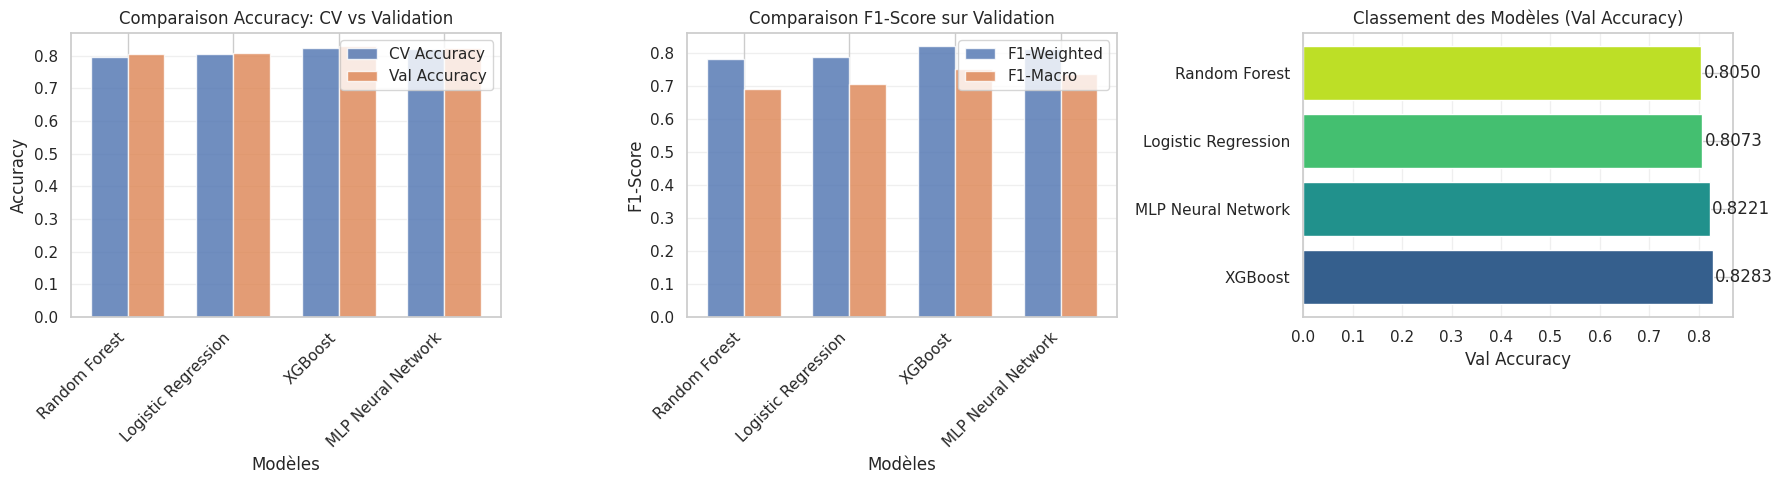

In [37]:
# Visualisation comparative des performances des modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Préparer les données pour la visualisation
model_names = list(results.keys())
cv_scores = [results[m]['cv_accuracy'] for m in model_names]
val_acc_scores = [results[m]['val_accuracy'] for m in model_names]
val_f1_weighted = [results[m]['val_f1_weighted'] for m in model_names]
val_f1_macro = [results[m]['val_f1_macro'] for m in model_names]

# 1) Comparaison Accuracy (CV vs Validation)
x_pos = np.arange(len(model_names))
width = 0.35

axes[0].bar(x_pos - width/2, cv_scores, width, label='CV Accuracy', alpha=0.8)
axes[0].bar(x_pos + width/2, val_acc_scores, width, label='Val Accuracy', alpha=0.8)
axes[0].set_xlabel('Modèles')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparaison Accuracy: CV vs Validation')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2) Comparaison F1-Score (Weighted vs Macro)
axes[1].bar(x_pos - width/2, val_f1_weighted, width, label='F1-Weighted', alpha=0.8)
axes[1].bar(x_pos + width/2, val_f1_macro, width, label='F1-Macro', alpha=0.8)
axes[1].set_xlabel('Modèles')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Comparaison F1-Score sur Validation')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# 3) Ranking global des modèles (par Val Accuracy)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(model_names)))
sorted_indices = np.argsort(val_acc_scores)[::-1]
sorted_names = [model_names[i] for i in sorted_indices]
sorted_scores = [val_acc_scores[i] for i in sorted_indices]

axes[2].barh(sorted_names, sorted_scores, color=colors)
axes[2].set_xlabel('Val Accuracy')
axes[2].set_title('Classement des Modèles (Val Accuracy)')
axes[2].grid(axis='x', alpha=0.3)

# Afficher les valeurs sur les barres
for i, (name, score) in enumerate(zip(sorted_names, sorted_scores)):
    axes[2].text(score + 0.005, i, f'{score:.4f}', va='center')

plt.tight_layout()
plt.show()